# Benchmarking CATE estimators on real truck sensor data (Scania APS)

**Question:** if you estimate *who benefits most* from a maintenance program (the conditional average treatment effect, CATE), do the standard estimators still work when the covariates are real sensor counters instead of the well-behaved Gaussians of a tutorial?

This dataset is a good stress test: 60,000 Scania trucks in everyday road operation, 170 anonymized operational counters and histogram bins, heavy tails, missing values and exactly collinear columns.

**What is real and what is simulated.** Real sensor data never comes with a known treatment effect, so the estimators could not be scored against the truth. This notebook uses a *semi-synthetic* design:

- **Real:** every model feature (`X`), untouched, and the dataset's own APS failure label.
- **Simulated:** a randomized maintenance pilot (treatment `T`, block-randomized) and the downtime outcome, with a **known heterogeneous effect** driven by real columns. Because the true effect is known for every truck, each estimate can be scored against it.

It compares three estimators over **20 seeds** (each redraws a 3,000-truck pilot, the assignment, the noise and a 60/40 train/test split): EconML's `CausalForestDML`, EconML's `DRLearner` with its default linear final stage, and a `DRLearner` whose final stage is Ridge regression applied after a log transform of only the skewed columns.

Everything here is a self-contained port of the benchmark in [chile-mining-fleet-causal-impact](https://github.com/Rxyxs/chile-mining-fleet-causal-impact), where the full design, the ablation behind the skew-aware variant, and the comparison against a fully synthetic pilot live.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("econml") is None:  # not preinstalled on Kaggle
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "econml"])

In [2]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from econml.dml import CausalForestDML
from econml.dr import DRLearner
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore")
import econml, lightgbm, sklearn
print(f"econml {econml.__version__} | lightgbm {lightgbm.__version__} | scikit-learn {sklearn.__version__} | numpy {np.__version__}")
SEEDS = list(range(100, 120))
N_UNITS = 3000

econml 0.17.0 | lightgbm 4.7.0 | scikit-learn 1.7.2 | numpy 2.2.6


## 1. The real covariates

The loader finds the header row itself: the UCI copy of this file starts with a 20-line license block, other copies do not.

In [3]:
CANDIDATES = sorted(Path("/kaggle/input").glob("**/aps_failure_training_set.csv")) + [Path("data/raw/aps_failure_training_set.csv")]
path = next((p for p in CANDIDATES if p.exists()), None)
assert path is not None, "Add the 'uciml/aps-failure-at-scania-trucks-data-set' dataset to this notebook."

with open(path, encoding="utf-8", errors="ignore") as f:
    header_row = next(i for i, line in enumerate(f) if line.startswith("class,"))
raw = pd.read_csv(path, skiprows=header_row, na_values="na")

X_all = raw.drop(columns="class").astype(float)
failure_all = (raw["class"] == "pos").astype(int)

corr = X_all.corr().abs().to_numpy()
np.fill_diagonal(corr, 0)
print(f"{len(X_all):,} trucks, {X_all.shape[1]} features, real APS failure rate {failure_all.mean():.2%}")
print(f"missing cells: {X_all.isna().to_numpy().mean():.1%}")
print(f"median |skew| per feature: {X_all.skew().abs().median():.1f}   (a Gaussian feature is ~0)")
print(f"feature pairs with |corr| > 0.99: {int((corr > 0.99).sum() / 2)}")

60,000 trucks, 170 features, real APS failure rate 1.67%
missing cells: 8.3%


median |skew| per feature: 17.5   (a Gaussian feature is ~0)
feature pairs with |corr| > 0.99: 14


## 2. The semi-synthetic pilot

- **Assignment:** complete randomization within 3 usage blocks (terciles of `aa_000`), treating exactly 45% / 50% / 55% of each block, so the propensity is known but not constant.
- **Untreated downtime** over the next 30 days: `mu0 = 20 h * exp(0.25 z_wear + 0.20 z_stress + 0.15 z_load) + repair_hours * F`, where the drivers are three real counters (`aa_000`, `ci_000`, `bj_000`), standardized by median/IQR after `log1p` and clipped to +-3, and `F` is the truck's **real** failure label.
- **Effect:** a proportional reduction `r(x) = clip(0.18 + 0.06 z_wear + 0.05 z_stress, 0.03, 0.55)`. The true CATE is `r(x) * mu0` hours saved.
- **Outcome:** `Y ~ Gamma(shape 2.2, mean mu0 or mu0 (1 - r))`. It is never clipped at zero: a `max(0, Y0 - tau)` floor would change the effect of exactly the truncated trucks and the recorded truth would stop being true.

Two conditions: without real failures in the baseline (`repair_hours = 0`) and with them (`repair_hours = 60`).

In [4]:
def robust_z(x, log_scale=True):
    v = np.log1p(x.clip(lower=0)) if log_scale else x.astype(float)
    scale = (v.quantile(0.75) - v.quantile(0.25)) / 1.349
    return np.clip(((v - v.median()) / scale).fillna(0.0).to_numpy(), -3.0, 3.0)

Z_WEAR, Z_STRESS, Z_LOAD = robust_z(X_all["aa_000"]), robust_z(X_all["ci_000"]), robust_z(X_all["bj_000"])
BLOCK_ALL = pd.qcut(X_all["aa_000"].rank(method="first"), q=3, labels=["usage_low", "usage_mid", "usage_high"]).astype(str)


def assign_block_randomized(block, rng, probs=(0.45, 0.50, 0.55)):
    treated = np.zeros(len(block), dtype=int)
    values = block.to_numpy()
    for i, label in enumerate(sorted(pd.unique(values))):
        idx = np.flatnonzero(values == label)
        treated[rng.choice(idx, size=int(round(probs[i % len(probs)] * len(idx))), replace=False)] = 1
    return treated


def simulate_pilot(seed, repair_hours, n=N_UNITS):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_all), size=n, replace=False)
    df = X_all.iloc[idx].reset_index(drop=True)
    block = BLOCK_ALL.iloc[idx].reset_index(drop=True)
    failure = failure_all.iloc[idx].to_numpy()
    zw, zs, zl = Z_WEAR[idx], Z_STRESS[idx], Z_LOAD[idx]

    baseline = 20.0 * np.exp(0.25 * zw + 0.20 * zs + 0.15 * zl) + repair_hours * failure
    reduction = np.clip(0.18 + 0.06 * zw + 0.05 * zs, 0.03, 0.55)
    treated = assign_block_randomized(block, rng)
    arm_mean = np.where(treated == 1, baseline * (1 - reduction), baseline)

    df["treated"] = treated
    df["y"] = rng.gamma(shape=2.2, scale=arm_mean / 2.2)
    df["true_cate"] = baseline * reduction
    return df


demo = simulate_pilot(100, repair_hours=60.0)
print(f"treated share: {demo.treated.mean():.1%}   mean true CATE: {demo.true_cate.mean():.2f} h   "
      f"range: {demo.true_cate.min():.2f} to {demo.true_cate.max():.2f} h")

treated share: 50.1%   mean true CATE: 3.36 h   range: 0.11 to 34.42 h


## 3. Estimators

All three share the same LightGBM nuisance models and see the same matrix: columns missing in more than half of the **training** rows are dropped and the rest are median-imputed with **training** medians.

- **Causal Forest DML**: EconML defaults plus `min_samples_leaf=20`.
- **DRLearner, default linear final stage** (`StatsModelsLinearRegression`, `min_propensity=0.1`).
- **DRLearner, skew-aware Ridge final stage**: `log1p` only on columns with |skew| > 1 **on the training matrix**, then standardization and `RidgeCV`. The columns are chosen with a callable, because EconML hands the final stage a NumPy array without column names. The threshold of 1 was fixed before running; the repo checks 0.5 / 2 / 5 as a sensitivity analysis.

In [5]:
def lgbm_reg():
    return LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, num_leaves=31, random_state=42, verbosity=-1)

def lgbm_clf():
    return LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, num_leaves=31, random_state=42, verbosity=-1)


class SkewedColumns:
    """Picks |skew| > threshold columns when the ColumnTransformer is fit, i.e. on train only."""
    def __init__(self, threshold):
        self.threshold = threshold
    def __call__(self, X):
        with np.errstate(invalid="ignore", divide="ignore"):
            s = stats.skew(np.asarray(X, dtype=float), axis=0, nan_policy="omit")
        return np.flatnonzero(np.nan_to_num(np.abs(s), nan=0.0) > self.threshold)


def signed_log1p(X):
    return np.sign(X) * np.log1p(np.abs(X))


def skew_aware_ridge(threshold=1.0):
    return make_pipeline(
        ColumnTransformer([("log", FunctionTransformer(signed_log1p), SkewedColumns(threshold))], remainder="passthrough"),
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-2, 5, 15)),
    )


def dr_learner(model_final):
    return DRLearner(model_propensity=lgbm_clf(), model_regression=lgbm_reg(), model_final=model_final,
                     cv=3, min_propensity=0.1, random_state=42)


ESTIMATORS = {
    "Causal Forest DML": lambda: CausalForestDML(model_y=lgbm_reg(), model_t=lgbm_clf(), discrete_treatment=True,
                                                 n_estimators=300, min_samples_leaf=20, cv=3, random_state=42),
    "DRLearner (linear)": lambda: dr_learner(StatsModelsLinearRegression()),
    "DRLearner (skew-aware Ridge)": lambda: dr_learner(skew_aware_ridge(1.0)),
}


def preprocess(train, test, features):
    Xtr, Xte = train[features].copy(), test[features].copy()
    keep = Xtr.columns[Xtr.isna().mean() <= 0.5]
    Xtr, Xte = Xtr[keep], Xte[keep]
    med = Xtr.median()
    return Xtr.fillna(med).to_numpy(float), Xte.fillna(med).to_numpy(float)

## 4. Run: 2 conditions x 20 seeds x 3 estimators

Scores are computed on the 1,200 held-out trucks of each split:

- **Pearson** and **Spearman** correlation with the true CATE;
- **wrong-sign share** (the true effect is always positive);
- **RMSE / std(true CATE)**;
- **targeting value**: the true hours saved by treating the top 30% ranked by predicted CATE, as a share of what ranking by the true CATE would save.

Runtime is about 15 minutes on a CPU.

In [6]:
FEATURES = list(X_all.columns)
rows, examples = [], {}
start = time.perf_counter()
for condition, repair in [("Scania", 0.0), ("Scania + real failures", 60.0)]:
    for seed in SEEDS:
        df = simulate_pilot(seed, repair)
        train, test = train_test_split(df, test_size=0.4, random_state=seed, stratify=df["treated"])
        Xtr, Xte = preprocess(train, test, FEATURES)
        tau = test["true_cate"].to_numpy()
        budget = int(round(len(tau) * 0.30))
        oracle_value = np.sort(tau)[::-1][:budget].sum()
        for name, make in ESTIMATORS.items():
            model = make().fit(train["y"].to_numpy(), train["treated"].to_numpy(), X=Xtr)
            pred = -model.effect(Xte)  # effect of T on downtime is negative; flip to "hours saved"
            rows.append({
                "condition": condition, "seed": seed, "estimator": name,
                "pearson": np.corrcoef(pred, tau)[0, 1],
                "spearman": stats.spearmanr(pred, tau)[0],
                "wrong_sign_pct": (pred < 0).mean() * 100,
                "nrmse": np.sqrt(np.mean((pred - tau) ** 2)) / tau.std(),
                "targeting_value": tau[np.argsort(-pred)[:budget]].sum() / oracle_value,
            })
            if seed == SEEDS[0]:
                examples[(condition, name)] = (tau, pred)
    print(f"{condition}: done ({time.perf_counter() - start:.0f}s elapsed)")

results = pd.DataFrame(rows)

Scania: done (346s elapsed)


Scania + real failures: done (683s elapsed)


## 5. Results

In [7]:
summary = results.groupby(["condition", "estimator"]).agg(
    pearson=("pearson", "mean"), pearson_sd=("pearson", "std"), worst_seed=("pearson", "min"),
    spearman=("spearman", "mean"), wrong_sign_pct=("wrong_sign_pct", "mean"),
    nrmse_median=("nrmse", "median"), nrmse_max=("nrmse", "max"), targeting_value=("targeting_value", "mean"),
)
summary.round(3)

pearson  pearson_sd  \
condition              estimator                                           
Scania                 Causal Forest DML               0.853       0.077   
                       DRLearner (linear)             -0.007       0.061   
                       DRLearner (skew-aware Ridge)    0.788       0.074   
Scania + real failures Causal Forest DML               0.702       0.104   
                       DRLearner (linear)             -0.008       0.107   
                       DRLearner (skew-aware Ridge)    0.609       0.096   

                                                     worst_seed  spearman  \
condition              estimator                                            
Scania                 Causal Forest DML                  0.655     0.877   
                       DRLearner (linear)                -0.138     0.219   
                       DRLearner (skew-aware Ridge)       0.591     0.844   
Scania + real failures Causal Forest DML                  0.453     0.888   
                       DRLearner (linear)                -0.223     0.176   
                       DRLearner (skew-aware Ridge)       0.392     0.812   

                                                     wrong_sign_pct  \
condition              estimator                                      
Scania                 Causal Forest DML                      2.750   
                       DRLearner (linear)                    32.688   
                       DRLearner (skew-aware Ridge)           6.783   
Scania + real failures Causal Forest DML                      2.158   
                       DRLearner (linear)                    34.379   
                       DRLearner (skew-aware Ridge)           8.983   

                                                     nrmse_median  \
condition              estimator                                    
Scania                 Causal Forest DML                    0.575   
                       DRLearner (linear)                 892.035   
                       DRLearner (skew-aware Ridge)         0.704   
Scania + real failures Causal Forest DML                    0.745   
                       DRLearner (linear)                1368.522   
                       DRLearner (skew-aware Ridge)         0.877   

                                                       nrmse_max  \
condition              estimator                                   
Scania                 Causal Forest DML                   0.912   
                       DRLearner (linear)            2619802.216   
                       DRLearner (skew-aware Ridge)        1.342   
Scania + real failures Causal Forest DML                   1.009   
                       DRLearner (linear)            6052351.734   
                       DRLearner (skew-aware Ridge)        2.273   

                                                     targeting_value  
condition              estimator                                      
Scania                 Causal Forest DML                       0.916  
                       DRLearner (linear)                      0.771  
                       DRLearner (skew-aware Ridge)            0.913  
Scania + real failures Causal Forest DML                       0.924  
                       DRLearner (linear)                      0.729  
                       DRLearner (skew-aware Ridge)            0.895

In [8]:
def paired_gap(metric, a, b):
    out = []
    for condition, g in results.groupby("condition"):
        p = g.pivot(index="seed", columns="estimator", values=metric)
        d = p[a] - p[b]
        lo, hi = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=stats.sem(d))
        out.append({"condition": condition, "metric": metric, "mean_gap": d.mean(), "ci95_low": lo, "ci95_high": hi,
                    "seeds where Causal Forest wins": int((d > 0).sum())})
    return pd.DataFrame(out)

pd.concat([paired_gap(m, "Causal Forest DML", "DRLearner (skew-aware Ridge)") for m in ["pearson", "targeting_value"]]).round(3)

,condition,metric,mean_gap,ci95_low,ci95_high,seeds where Causal Forest wins
0,Scania,pearson,0.065,0.026,0.103,16
1,Scania + real failures,pearson,0.094,0.028,0.160,16
0,Scania,targeting_value,0.003,-0.034,0.040,12
1,Scania + real failures,targeting_value,0.029,-0.024,0.083,14


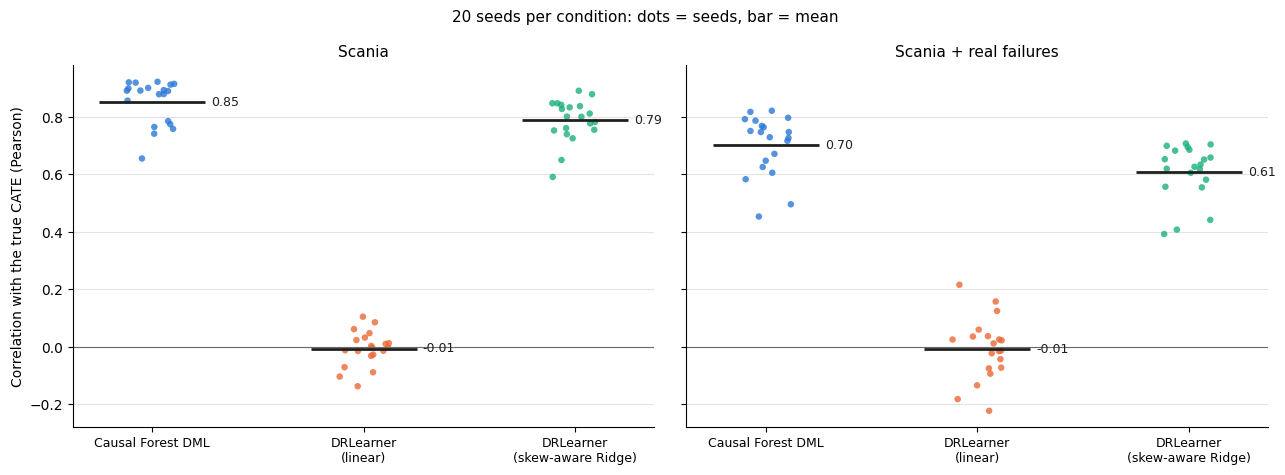

In [9]:
COLORS = {"Causal Forest DML": "#2a78d6", "DRLearner (linear)": "#eb6834", "DRLearner (skew-aware Ridge)": "#1baf7a"}
conditions = ["Scania", "Scania + real failures"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
rng = np.random.default_rng(0)
for ax, condition in zip(axes, conditions):
    for j, name in enumerate(COLORS):
        v = results.query("condition == @condition and estimator == @name")["pearson"].to_numpy()
        ax.scatter(j + rng.uniform(-0.12, 0.12, len(v)), v, s=22, color=COLORS[name], alpha=0.8, edgecolors="none")
        ax.hlines(v.mean(), j - 0.25, j + 0.25, color="#1f1f1e", linewidth=2)
        ax.annotate(f"{v.mean():.2f}", (j + 0.28, v.mean()), va="center", fontsize=9, color="#1f1f1e")
    ax.axhline(0, color="#6b6a64", linewidth=0.8)
    ax.set_xticks(range(len(COLORS)), [n.replace(" (", "\n(") for n in COLORS], fontsize=9)
    ax.set_title(condition, fontsize=11)
    ax.grid(axis="y", color="#e4e3dd"); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("Correlation with the true CATE (Pearson)")
fig.suptitle("20 seeds per condition: dots = seeds, bar = mean", fontsize=11)
fig.tight_layout()
plt.show()

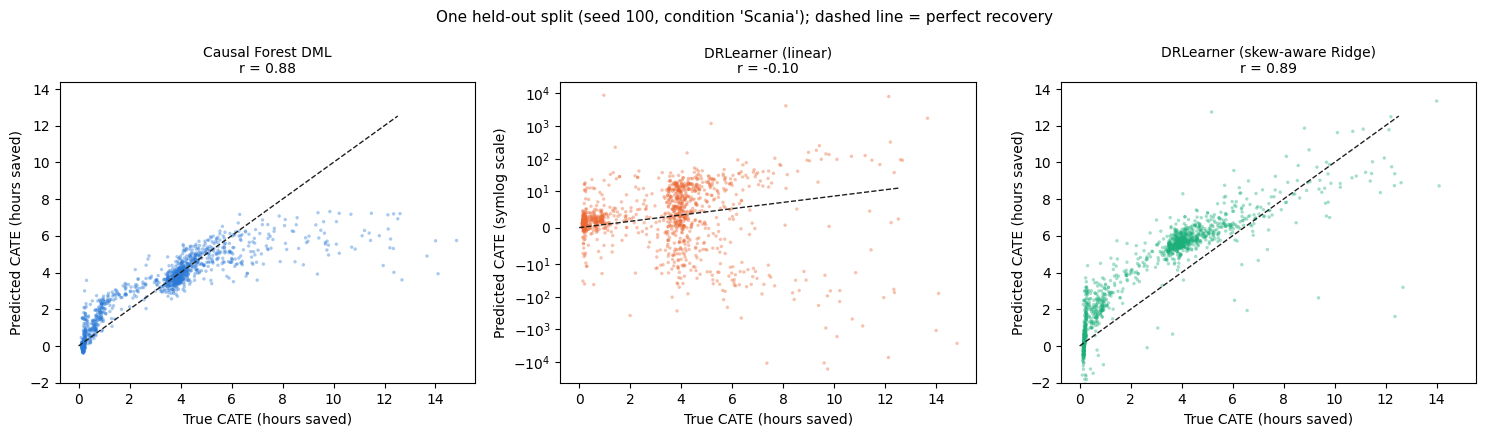

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, name in zip(axes, COLORS):
    tau, pred = examples[("Scania", name)]
    ax.scatter(tau, pred, s=6, alpha=0.4, color=COLORS[name], edgecolors="none")
    lim = [0, np.quantile(tau, 0.995)]
    ax.plot(lim, lim, color="#1f1f1e", linewidth=1, linestyle="--")
    if name == "DRLearner (linear)":
        ax.set_yscale("symlog", linthresh=10)  # its predictions span -1e4 to 1e4 hours; a linear axis would show nothing
        ax.set_ylabel("Predicted CATE (symlog scale)")
    else:
        ax.set_ylim(-2, lim[1] * 1.15)
        ax.set_ylabel("Predicted CATE (hours saved)")
    ax.set_title(f"{name}\nr = {np.corrcoef(pred, tau)[0, 1]:.2f}", fontsize=10)
    ax.set_xlabel("True CATE (hours saved)")
fig.suptitle(f"One held-out split (seed {SEEDS[0]}, condition 'Scania'); dashed line = perfect recovery", fontsize=11)
fig.tight_layout()
plt.show()

## 6. What the numbers say

Numbers quoted from the run saved with this version (library versions printed at the top). A rerun with other library versions may shift them slightly.

1. **The default `DRLearner` collapses on these covariates.** The mean correlation with the true CATE is −0.007 without real failures in the baseline and −0.008 with them. About a third of its predictions have the wrong sign, and its median RMSE is roughly 900–1,400 times the spread of the true effect. The scatter shows why: individual predictions reach ±10,000 hours for effects that never exceed about 35.
2. **A skew-aware Ridge final stage rescues it**: 0.788 and 0.609, with a seed-to-seed spread (0.07–0.10) as tight as the Causal Forest's. It still gets the sign wrong more often (7–9% vs. 2–3%), and in the example split it overestimates mid-range trucks: most of its points sit above the diagonal.
3. **Causal Forest DML recovers the CATE best, but that lead does not carry over to the targeting decision.** Its paired correlation gap over the skew-aware DR is +0.065 (95% CI +0.026 to +0.103) and +0.094 (+0.028 to +0.160). In true hours saved by treating the top 30% of the fleet, the gap is +0.003 (−0.034 to +0.040) and +0.029 (−0.024 to +0.083), which is not distinguishable from zero.
4. **Causal Forest ranks well but compresses magnitudes**: in the scatter, its predictions flatten out around 6–7 hours while the true effect keeps growing. Use it to decide *who* to treat; calibrate it before quoting *how many hours* it saves.
5. **Real failure structure is the hard part**: once the dataset's real APS failures enter the baseline, both working estimators lose 0.15–0.18 of correlation (Causal Forest 0.853 → 0.702, skew-aware DR 0.788 → 0.609).

**Why the linear DR breaks, and what this notebook does not show.** An ablation in the [repo](https://github.com/Rxyxs/chile-mining-fleet-causal-impact/blob/main/outputs/reports/semi_synthetic_results.md) found that neither a log transform alone nor Ridge alone fixes it; both are needed. That points to extrapolation on extreme counters plus collinearity in `X`. The ablation did not isolate pseudo-outcome noise as the cause. The effect itself is simulated, so this tests the estimators against real covariate distributions, not against a real treatment effect. On better-behaved covariates (the AI4I 2020 dataset in the repo) the skew-aware DR beats the Causal Forest, so "Causal Forest wins" is not a universal rule.